# **TRAINING MODEL DATASET**

# **1. Setup & Install**

Cell ini mengimpor semua library yang dibutuhkan untuk training: tensorflow/keras untuk membangun dan melatih model, matplotlib untuk visualisasi grafik training, numpy untuk operasi angka, dan beberapa modul bawaan Python (os, zipfile, pathlib) untuk menangani file. Di akhir, dicek apakah GPU tersedia — kalau hasilnya list kosong, berarti kamu belum mengaktifkan GPU di Runtime settings.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os, zipfile, pathlib

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **2. Upload Dataset**

Cell ini memunculkan dialog upload file. Pilih corn_dataset_clean (1).zip — dataset yang sudah bersih dari notebook EDA, bukan archive_1.zip yang mentah.

In [3]:
from google.colab import files

uploaded = files.upload()  # pilih corn_dataset_clean (1).zip
zip_path = list(uploaded.keys())[0]
print("File terupload:", zip_path)

Saving corn_dataset_clean.zip to corn_dataset_clean (1).zip
File terupload: corn_dataset_clean (1).zip


# **3. Ekstrak Dataset (auto-detect struktur folder)**

Ini bagian yang memperbaiki error kamu sebelumnya. File zip diekstrak dulu, lalu sistem mengecek sendiri apakah ada subfolder data/ di dalamnya (seperti di archive.zip mentah) atau kelas-kelasnya langsung ada di folder paling atas (seperti hasil corn_dataset_clean.zip). Dengan begitu, data_dir otomatis menunjuk ke lokasi yang benar, tidak peduli file mana yang kamu upload. Di akhir, ada pengecekan (assert) yang akan langsung kasih pesan jelas kalau ternyata nama foldernya tidak sesuai dugaan.

In [4]:
import zipfile
import pathlib

extract_dir = '/content/corn_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

extract_root = pathlib.Path(extract_dir)
if (extract_root / 'data').is_dir():
    data_dir = extract_root / 'data'
else:
    data_dir = extract_root

EXPECTED_CLASSES = {'Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy'}
found_classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

assert set(found_classes) == EXPECTED_CLASSES, (
    f"Struktur folder tidak sesuai dugaan. Ditemukan: {found_classes}."
)

print(f"Dataset dibaca dari: {data_dir}")
print("Kelas ditemukan:", found_classes)

for class_dir in sorted(data_dir.iterdir()):
    if class_dir.is_dir():
        n_images = len(list(class_dir.glob('*')))
        print(f"{class_dir.name}: {n_images} gambar")

Dataset dibaca dari: /content/corn_dataset
Kelas ditemukan: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Blight: 925 gambar
Common_Rust: 1163 gambar
Gray_Leaf_Spot: 476 gambar
Healthy: 1068 gambar


# **4. Membangun Dataset (Train/Validation Split)**

Cell ini membagi data jadi dua bagian: 80% untuk training, 20% untuk validasi (validation_split=0.2), memakai seed yang sama supaya pembagiannya konsisten tiap kali dijalankan ulang. Semua gambar otomatis di-resize ke 224×224 piksel (ukuran standar input MobileNetV2) dan dikelompokkan dalam batch isi 32 gambar. Di baris terakhir, .cache() dan .prefetch() dipakai supaya proses loading gambar tidak jadi bottleneck yang bikin training lambat.

In [5]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Kelas:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3632 files belonging to 4 classes.
Using 2906 files for training.
Found 3632 files belonging to 4 classes.
Using 726 files for validation.
Kelas: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


# **5. Data Augmentation**

Cell ini mendefinisikan transformasi acak yang akan diterapkan ke gambar training setiap kali dipakai (flip horizontal, rotasi ringan, zoom, dan kontras) — tujuannya supaya model tidak sekadar "menghafal" gambar training, tapi belajar mengenali pola penyakit dari berbagai sudut pandang. Ini penting karena jumlah data per kelas tidak seimbang (Gray_Leaf_Spot paling sedikit).

In [6]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# **6. Membangun Model (MobileNetV2 Transfer Learning)**

Ini jantung dari proses training. MobileNetV2 dimuat dengan bobot yang sudah dilatih sebelumnya di dataset ImageNet (weights='imagenet'), lalu bagian "kepala" klasifikasinya dibuang (include_top=False) karena kita mau ganti dengan klasifikasi 4 kelas sendiri. base_model.trainable = False berarti seluruh bobot MobileNetV2 dibekukan dulu — model hanya belajar lewat layer baru yang kita tambahkan di atasnya (GlobalAveragePooling2D, Dropout, dan Dense dengan aktivasi softmax untuk 4 kelas).

In [7]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
)
base_model.trainable = False  # freeze dulu

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **7. Training Tahap 1 (Feature Extraction)**

Ini tahap training pertama, dengan base model MobileNetV2 masih dibekukan — hanya layer klasifikasi baru yang dilatih. EarlyStopping dipasang supaya training otomatis berhenti kalau val_loss tidak membaik selama 4 epoch berturut-turut (mencegah overfitting & buang waktu). Setelah training selesai, grafik akurasi dan loss (training vs validasi) ditampilkan untuk melihat apakah modelnya belajar dengan baik atau malah overfitting.

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.7935 - loss: 0.5157 - val_accuracy: 0.9022 - val_loss: 0.2431
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9109 - loss: 0.2314 - val_accuracy: 0.9449 - val_loss: 0.1716
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9198 - loss: 0.1988 - val_accuracy: 0.9380 - val_loss: 0.1590
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9295 - loss: 0.1714 - val_accuracy: 0.9311 - val_loss: 0.1582
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9394 - loss: 0.1640 - val_accuracy: 0.9504 - val_loss: 0.1370
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9319 - loss: 0.1630 - val_accuracy: 0.9366 - val_loss: 0.1402
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9460 - loss: 0.1409 - val_accuracy: 0.9545 - val_loss: 0.1312
Epoch 8/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9405 - loss: 0.1428 - val_accuracy: 0.9532 -

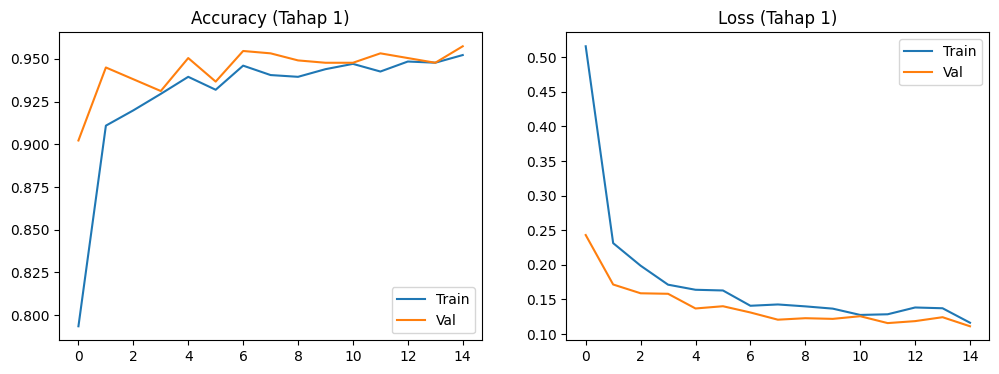

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

EPOCHS = 15
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[early_stop])

def plot_history(history, title=''):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(acc, label='Train'); plt.plot(val_acc, label='Val'); plt.legend(); plt.title(f'Accuracy {title}')
    plt.subplot(1, 2, 2); plt.plot(loss, label='Train'); plt.plot(val_loss, label='Val'); plt.legend(); plt.title(f'Loss {title}')
    plt.show()

plot_history(history, '(Tahap 1)')

# **8. Training Tahap 2 (Fine-Tuning)**

Sekarang base model "dicairkan" (base_model.trainable = True), tapi hanya layer-layer paling atas (setelah index 100) yang ikut dilatih ulang — layer-layer awal tetap dibekukan karena biasanya menyimpan fitur dasar yang sudah bagus (tepi, tekstur, warna). Model di-compile ulang dengan learning rate jauh lebih kecil (1e-5 vs 1e-3 sebelumnya) supaya bobot yang sudah bagus tidak "rusak" karena update yang terlalu besar. Training dilanjutkan dari epoch terakhir tahap 1, bukan dari nol lagi.

Epoch 16/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.9030 - loss: 0.2524 - val_accuracy: 0.9545 - val_loss: 0.1085
Epoch 17/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9301 - loss: 0.1956 - val_accuracy: 0.9518 - val_loss: 0.1125
Epoch 18/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9363 - loss: 0.1774 - val_accuracy: 0.9573 - val_loss: 0.1123
Epoch 19/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9443 - loss: 0.1614 - val_accuracy: 0.9573 - val_loss: 0.1088
Epoch 20/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9436 - loss: 0.1443 - val_accuracy: 0.9601 - val_loss: 0.1087


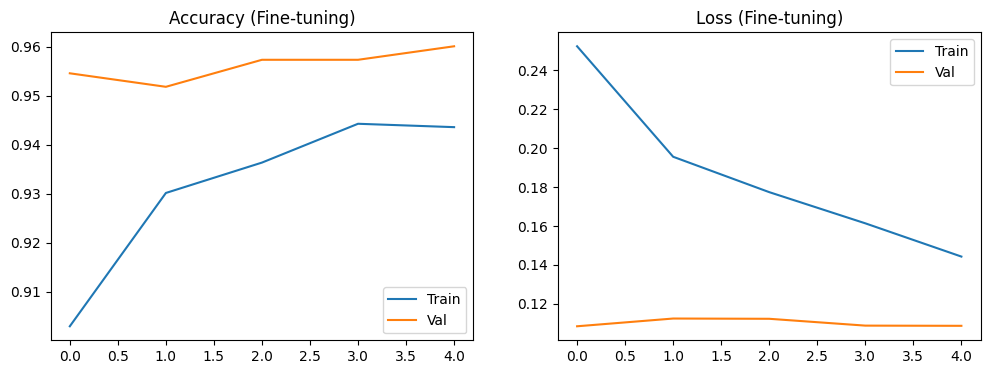

In [9]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs
history_fine = model.fit(
    train_ds, validation_data=val_ds, epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1, callbacks=[early_stop]
)
plot_history(history_fine, '(Fine-tuning)')

# **9. Evaluasi Model**

Cell ini menjalankan model terhadap seluruh data validasi, mengumpulkan prediksinya, lalu membandingkan dengan label aslinya. Hasilnya ditampilkan dalam dua bentuk: classification report (precision, recall, f1-score per kelas — di sinilah kamu cek apakah Gray_Leaf_Spot recall-nya jelek karena datanya sedikit) dan confusion matrix (heatmap yang menunjukkan kelas mana sering tertukar dengan kelas lain).

                precision    recall  f1-score   support

        Blight       0.94      0.89      0.92       188
   Common_Rust       0.99      0.99      0.99       224
Gray_Leaf_Spot       0.81      0.88      0.84        91
       Healthy       1.00      1.00      1.00       223

      accuracy                           0.95       726
     macro avg       0.93      0.94      0.94       726
  weighted avg       0.96      0.95      0.95       726



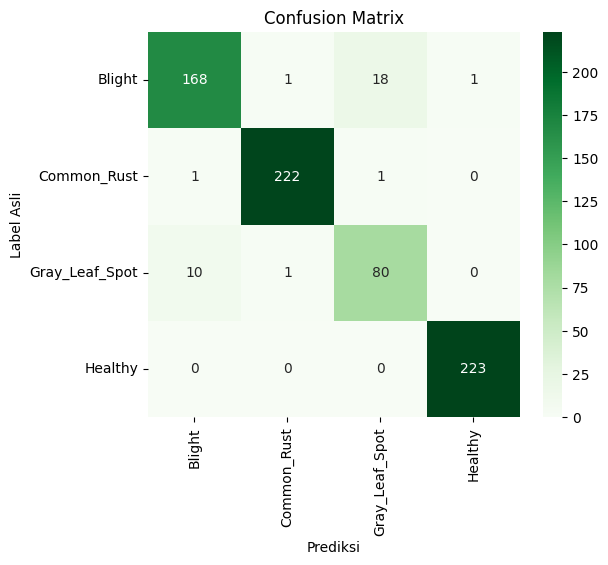

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Prediksi'); plt.ylabel('Label Asli'); plt.title('Confusion Matrix')
plt.show()

# **10. Simpan & Download Model**

Cell terakhir: model disimpan dalam format .keras (format native TensorFlow terbaru, dipakai nanti oleh Django REST API di backend), sekaligus dikonversi ke .tflite (versi lebih ringan, kalau nanti dibutuhkan untuk inference di sisi mobile/edge). Kedua file langsung memicu dialog download ke komputer kamu.

In [11]:
model.save('mobilenet_corn_model.keras')
print("Model tersimpan sebagai mobilenet_corn_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('mobilenet_corn_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model TFLite tersimpan sebagai mobilenet_corn_model.tflite")

from google.colab import files
files.download('mobilenet_corn_model.keras')
files.download('mobilenet_corn_model.tflite')

Model tersimpan sebagai mobilenet_corn_model.keras
Saved artifact at '/tmp/tmpehdxvbnz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135756201503120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201503888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201503696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201504080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201501584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201503312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201504848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201504656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201505040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135756201500048: TensorSpec(s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell A. Log eksperimen terstruktur

Menggabungkan riwayat tahap 1 dan tahap 2 ke satu tabel, menyimpannya sebagai log_eksperimen.csv, dan menampilkan epoch dengan val_loss terendah.

In [12]:
import json, os, datetime
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('hasil_subtask3', exist_ok=True)

def history_to_df(h, tahap):
    d = pd.DataFrame(h.history)
    d['epoch'] = [e + 1 for e in h.epoch]
    d['tahap'] = tahap
    return d

log_df = pd.concat([
    history_to_df(history, 'Tahap 1 - Feature Extraction'),
    history_to_df(history_fine, 'Tahap 2 - Fine-tuning'),
], ignore_index=True)

log_df = log_df[['tahap', 'epoch', 'accuracy', 'val_accuracy', 'loss', 'val_loss']]
log_df.to_csv('hasil_subtask3/log_eksperimen.csv', index=False)

best_row = log_df.loc[log_df['val_loss'].idxmin()]
print("Epoch dengan val_loss terendah:")
print(best_row.to_string())
log_df.tail(8)

Epoch dengan val_loss terendah:
tahap           Tahap 2 - Fine-tuning
epoch                              16
accuracy                     0.902959
val_accuracy                 0.954545
loss                         0.252372
val_loss                     0.108472


,tahap,epoch,accuracy,val_accuracy,loss,val_loss
12,Tahap 1 - Feature Extraction,13,0.948383,0.950413,0.138433,0.118733
13,Tahap 1 - Feature Extraction,14,0.947694,0.947658,0.137329,0.124403
14,Tahap 1 - Feature Extraction,15,0.952168,0.957300,0.116408,0.111295
15,Tahap 2 - Fine-tuning,16,0.902959,0.954545,0.252372,0.108472
16,Tahap 2 - Fine-tuning,17,0.930145,0.951791,0.195588,0.112452
17,Tahap 2 - Fine-tuning,18,0.936339,0.957300,0.177407,0.112319
18,Tahap 2 - Fine-tuning,19,0.944253,0.957300,0.161383,0.108809
19,Tahap 2 - Fine-tuning,20,0.943565,0.960055,0.144293,0.108710


Cell B. Kurva akurasi dan loss gabungan

Satu grafik untuk seluruh training, dengan garis putus-putus yang menandai awal fine-tuning. Hasilnya disimpan sebagai PNG untuk laporan.

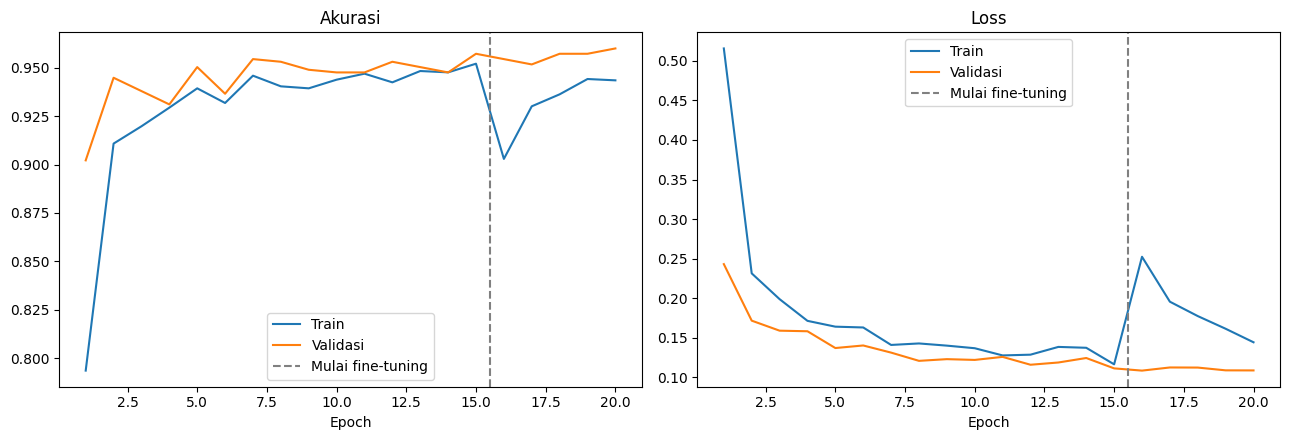

In [13]:
batas = len(history.epoch)   # batas antara tahap 1 dan tahap 2
x = log_df.index + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, log_df['accuracy'], label='Train')
axes[0].plot(x, log_df['val_accuracy'], label='Validasi')
axes[0].axvline(batas + 0.5, color='gray', linestyle='--', label='Mulai fine-tuning')
axes[0].set_title('Akurasi'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(x, log_df['loss'], label='Train')
axes[1].plot(x, log_df['val_loss'], label='Validasi')
axes[1].axvline(batas + 0.5, color='gray', linestyle='--', label='Mulai fine-tuning')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('hasil_subtask3/kurva_akurasi_loss.png', dpi=150)
plt.show()

Cell C. Evaluasi lengkap

Menjalankan model ke data validasi, lalu menyimpan classification report (CSV) dan dua confusion matrix (PNG). Matrix kedua dinormalisasi per kelas, jadi kelihatan persentase tiap kelas yang salah tebak, bukan cuma jumlah gambarnya.

                precision  recall  f1-score  support
Blight              0.939   0.894     0.916  188.000
Common_Rust         0.991   0.991     0.991  224.000
Gray_Leaf_Spot      0.808   0.879     0.842   91.000
Healthy             0.996   1.000     0.998  223.000
accuracy            0.955   0.955     0.955    0.955
macro avg           0.933   0.941     0.937  726.000
weighted avg        0.956   0.955     0.955  726.000


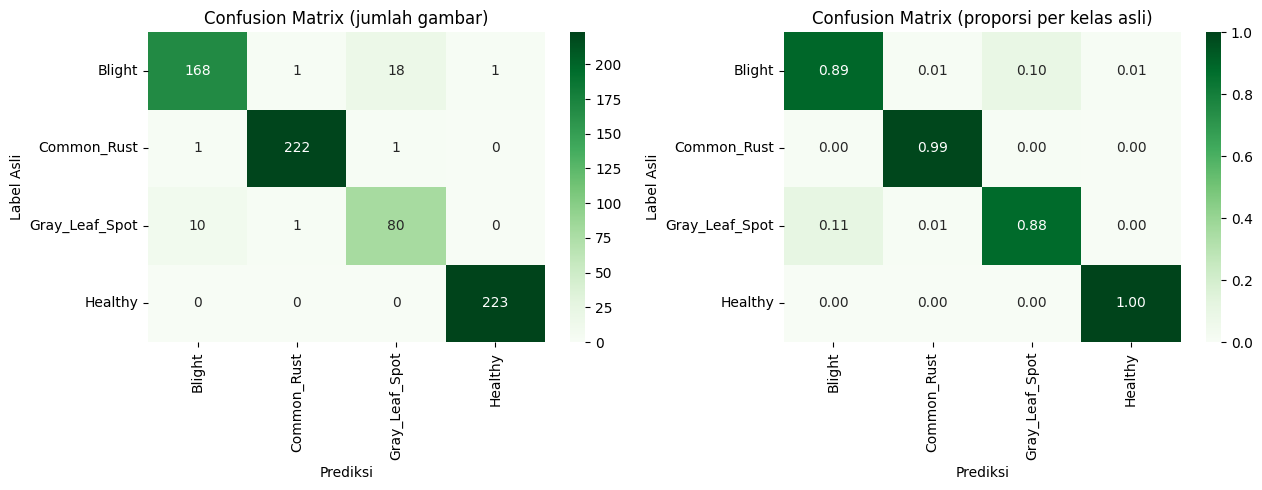

In [14]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred, val_images = [], [], []
for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))
    val_images.extend(images.numpy().astype('uint8'))   # simpan gambar untuk analisis kesalahan

y_true, y_pred = np.array(y_true), np.array(y_pred)

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv('hasil_subtask3/classification_report.csv')
print(report_df)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix (jumlah gambar)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix (proporsi per kelas asli)')
for a in axes:
    a.set_xlabel('Prediksi'); a.set_ylabel('Label Asli')
plt.tight_layout()
plt.savefig('hasil_subtask3/confusion_matrix.png', dpi=150)
plt.show()

Cell D. Analisis kesalahan prediksi

Mencetak pasangan kelas yang paling sering tertukar, lalu menampilkan 9 gambar yang salah diprediksi. Dari sini kamu bisa melihat langsung kenapa Blight sering dikira Gray_Leaf_Spot, misalnya karena bercak daunnya mirip atau foto kurang jelas.

Kesalahan terbanyak (kelas asli -> diprediksi sebagai):
  Blight -> Gray_Leaf_Spot: 18 gambar
  Gray_Leaf_Spot -> Blight: 10 gambar
  Blight -> Common_Rust: 1 gambar
  Blight -> Healthy: 1 gambar
  Common_Rust -> Blight: 1 gambar


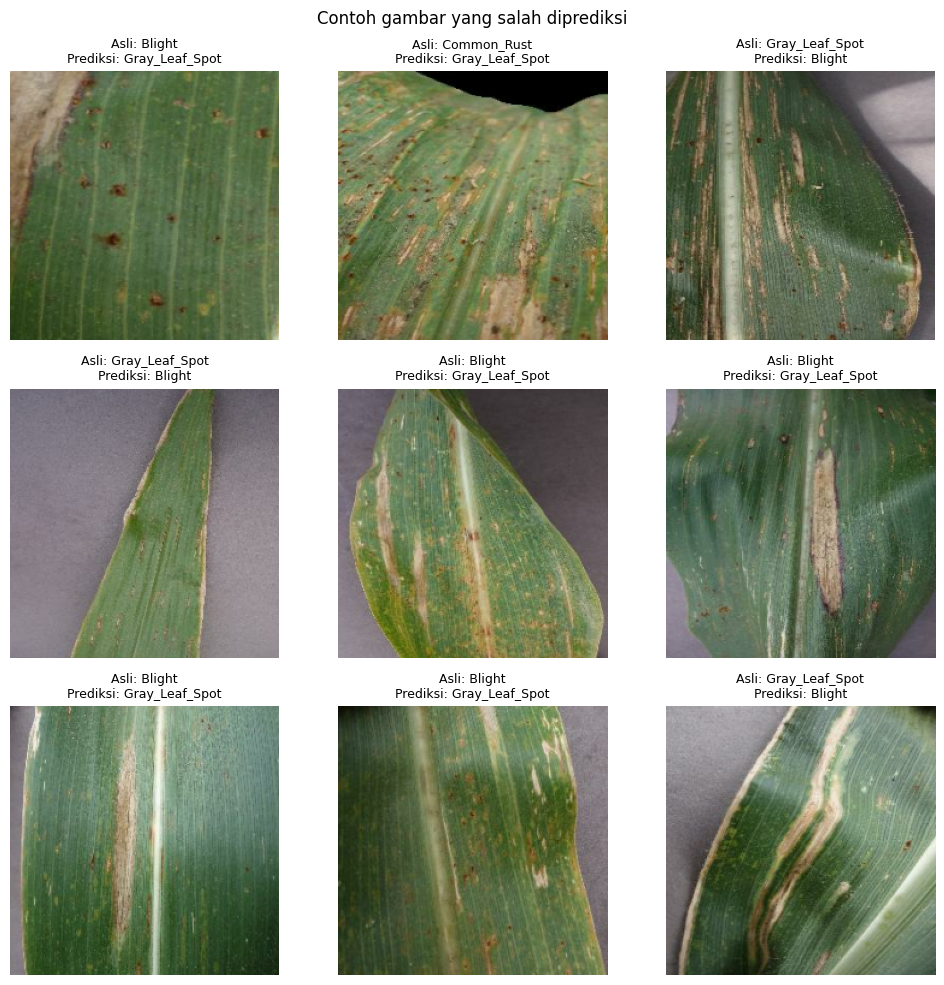

In [15]:
pairs = []
for i, a in enumerate(class_names):
    for j, b in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            pairs.append((a, b, int(cm[i, j])))
pairs.sort(key=lambda t: -t[2])

print("Kesalahan terbanyak (kelas asli -> diprediksi sebagai):")
for a, b, n in pairs[:5]:
    print(f"  {a} -> {b}: {n} gambar")

# Tampilkan contoh gambar yang salah prediksi
salah = np.where(y_true != y_pred)[0]
contoh = salah[:9]

plt.figure(figsize=(10, 10))
for k, idx in enumerate(contoh):
    plt.subplot(3, 3, k + 1)
    plt.imshow(val_images[idx])
    plt.title(f"Asli: {class_names[y_true[idx]]}\nPrediksi: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis('off')
plt.suptitle('Contoh gambar yang salah diprediksi')
plt.tight_layout()
plt.savefig('hasil_subtask3/contoh_salah_prediksi.png', dpi=150)
plt.show()

Cell E. Ringkasan metrik dan zip untuk dilampirkan

Merangkum konfigurasi dan hasil ke ringkasan_metrik.json, lalu mengemas semua file hasil jadi satu zip. Zip ini bisa dilampirkan ke issue #39 atau di-commit ke repo sebagai bukti.

In [16]:
ringkasan = {
    'tanggal': datetime.date.today().isoformat(),
    'arsitektur': 'MobileNetV2 (transfer learning, ImageNet)',
    'ukuran_input': list(IMG_SIZE),
    'batch_size': BATCH_SIZE,
    'epoch_tahap_1': len(history.epoch),
    'epoch_tahap_2': len(history_fine.epoch),
    'fine_tune_at': 100,
    'lr_tahap_1': 1e-3,
    'lr_tahap_2': 1e-5,
    'jumlah_data_validasi': int(len(y_true)),
    'akurasi_validasi': round(float((y_true == y_pred).mean()), 4),
    'macro_f1': round(report['macro avg']['f1-score'], 4),
    'weighted_f1': round(report['weighted avg']['f1-score'], 4),
    'recall_per_kelas': {c: round(report[c]['recall'], 3) for c in class_names},
    'precision_per_kelas': {c: round(report[c]['precision'], 3) for c in class_names},
    'val_loss_terbaik': round(float(log_df['val_loss'].min()), 4),
}
with open('hasil_subtask3/ringkasan_metrik.json', 'w') as f:
    json.dump(ringkasan, f, indent=2, ensure_ascii=False)
print(json.dumps(ringkasan, indent=2, ensure_ascii=False))

import shutil
from google.colab import files
shutil.make_archive('hasil_subtask3', 'zip', 'hasil_subtask3')
files.download('hasil_subtask3.zip')

{
  "tanggal": "2026-10-08",
  "arsitektur": "MobileNetV2 (transfer learning, ImageNet)",
  "ukuran_input": [
    224,
    224
  ],
  "batch_size": 32,
  "epoch_tahap_1": 15,
  "epoch_tahap_2": 5,
  "fine_tune_at": 100,
  "lr_tahap_1": 0.001,
  "lr_tahap_2": 1e-05,
  "jumlah_data_validasi": 726,
  "akurasi_validasi": 0.9545,
  "macro_f1": 0.9366,
  "weighted_f1": 0.9549,
  "recall_per_kelas": {
    "Blight": 0.894,
    "Common_Rust": 0.991,
    "Gray_Leaf_Spot": 0.879,
    "Healthy": 1.0
  },
  "precision_per_kelas": {
    "Blight": 0.939,
    "Common_Rust": 0.991,
    "Gray_Leaf_Spot": 0.808,
    "Healthy": 0.996
  },
  "val_loss_terbaik": 0.1085
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell F (opsional). Fine-tuning ulang yang lebih rapi

Pakai ini kalau mau mencoba memperbaiki hasil. Letakkan sebelum cell fine-tuning lama, tepat setelah tahap 1 selesai, dan aktifkan GPU dulu. Perubahannya:

Menyimpan snapshot model tahap 1 sebagai pembanding.
Memakai EarlyStopping baru, tidak memakai ulang objek dari tahap 1.
Menambah class_weight supaya kelas yang lebih sedikit (Gray_Leaf_Spot) mendapat bobot lebih.
Membuka lebih sedikit layer (dari layer 120).
Menyimpan checkpoint terbaik.
Membandingkan akurasi tahap 1 dengan hasil fine-tuning, lalu memberi tahu model mana yang sebaiknya di-export.

Setelah cell ini selesai, jalankan Cell A–E lagi supaya log dan metrik mengikuti hasil terbaru.

In [17]:
model.save('model_tahap1.keras')                      # snapshot sebelum fine-tuning
acc1 = model.evaluate(val_ds, verbose=0)[1]
print("Akurasi validasi tahap 1:", round(acc1, 4))

from sklearn.utils.class_weight import compute_class_weight
labels_train = np.concatenate([y.numpy() for _, y in train_ds])
cw = compute_class_weight('balanced', classes=np.unique(labels_train), y=labels_train)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("Class weight:", class_weight)

base_model.trainable = True
for layer in base_model.layers[:120]:                 # buka lebih sedikit layer (dari layer 120)
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    'model_terbaik.keras', monitor='val_loss', save_best_only=True
)
early2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

history_fine = model.fit(
    train_ds, validation_data=val_ds, epochs=len(history.epoch) + 10,
    initial_epoch=len(history.epoch),
    class_weight=class_weight, callbacks=[ckpt, early2]
)

acc2 = model.evaluate(val_ds, verbose=0)[1]
print(f"Tahap 1: {acc1:.4f}  |  Setelah fine-tuning: {acc2:.4f}")
if acc2 < acc1:
    print("Fine-tuning tidak membantu -> pakai model_tahap1.keras untuk export.")
else:
    print("Fine-tuning membantu -> pakai model_terbaik.keras untuk export.")

Akurasi validasi tahap 1: 0.9545
Class weight: {0: 0.985753052917232, 1: 0.7736954206602769, 2: 1.887012987012987, 3: 0.8597633136094674}
Epoch 16/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 0.9257 - loss: 0.2434 - val_accuracy: 0.9532 - val_loss: 0.1115
Epoch 17/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9336 - loss: 0.2164 - val_accuracy: 0.9518 - val_loss: 0.1187
Epoch 18/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9439 - loss: 0.1837 - val_accuracy: 0.9504 - val_loss: 0.1265
Epoch 19/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9443 - loss: 0.1789 - val_accuracy: 0.9504 - val_loss: 0.1224
Epoch 20/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9511 - loss: 0.1605 - val_accuracy: 0.9421 - val_loss: 0.1461
Tahap 1: 0.9545  |  Setelah fine-tuning: 0.9532
Fine-tuning tidak membantu -> pakai model_tahap1.keras untuk export.
